In [1]:
pip install medmnist

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   --------------- ------------------------ 5.0/12.8 MB 23.1 MB/s eta 0:00:01
   ----------------------------------- ---- 11.3/12.8 MB 28.2 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 25.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 23.6 MB/s  0:00:00
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   -- ------------------------------------- 7.3/114.5 MB 34.9 MB/s eta 0:00:04
   ----- ---------------------------------- 15.2/114.5 MB 36.8 MB/s eta 0:00:03
   ------- -------------------------------- 22.0/114.5 MB 35.7 MB/s eta 0:00:03
   ---------- ----------------------------- 29.4/114.5 MB 35.8 MB/s eta 0:00:03
   ------------ --------------------------- 36.7/114.5 MB 35.3 MB/s eta 0:00:03
   --------------- ------------------------ 44.6/114.5 MB 35.9 MB/s eta 0:00:02
   -

In [12]:
import medmnist
from medmnist import OrganCMNIST

# Make sure all three splits are loaded!
train_dataset = OrganCMNIST(split='train', download=True)
val_dataset = OrganCMNIST(split='val', download=True)
test_dataset = OrganCMNIST(split='test', download=True)

# Data Preprocessing 

In [19]:
import numpy as np

# Safely add the channel dimension (the '1') to the very end (axis=-1)
x_train_reshaped = np.expand_dims(x_train_normalized, axis=-1)
x_val_reshaped = np.expand_dims(x_val_normalized, axis=-1)

# Just to be 100% sure, print the shape before training!
# It should print: (23583, 28, 28, 1)
print("New training shape:", x_train_reshaped.shape)

New training shape: (12975, 28, 28, 1)


In [14]:
import os
# why is this here? This is disabling some tensorflow warning I get in some of my environments that 
# annoy me (look ugly and untidy really)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import keras
from keras.datasets import fashion_mnist
from keras import regularizers
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten
from keras.utils import to_categorical
from keras.models import Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

import numpy
import scipy.io

from sklearn.manifold import TSNE

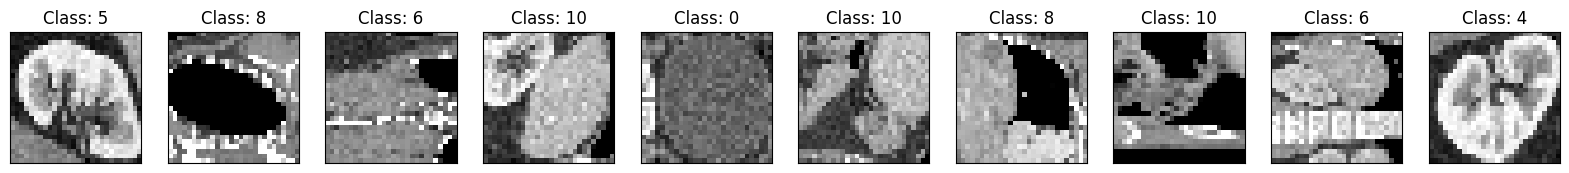

In [9]:
import matplotlib.pyplot as plt
from medmnist import OrganCMNIST

# 1. Load the dataset (if you haven't already in your notebook)
train_dataset = OrganCMNIST(split='train', download=True)

# 2. Extract the raw images and labels
# .imgs gets the array of images, .labels gets the array of class numbers
images = train_dataset.imgs
labels = train_dataset.labels

# 3. Set up a Matplotlib figure
n = 10 # Number of images to show
plt.figure(figsize=(20, 4))

for i in range(n):
    # Create a subplot for each image in a 1x10 grid
    ax = plt.subplot(1, n, i + 1)
    
    # Plot the image (it's already 28x28, so no reshaping needed)
    plt.imshow(images[i], cmap='gray')
    
    # Add the label as the title so you know what organ class it is
    # The [0] is just because the labels are formatted as arrays like [3]
    plt.title(f"Class: {labels[i][0]}")
    
    # Hide the axes for a cleaner look
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

# Display the plot
plt.show()

# Building the Network

In [28]:
from tensorflow import keras
from tensorflow.keras import layers, Model

# ==========================================
# 1. THE SHARED INPUT
# ==========================================
# Explicitly set to 28x28 grayscale
inputs = keras.Input(shape=(28, 28, 1), name='image_input')

# ==========================================
# 2. THE SHARED ENCODER (The Bottleneck)
# ==========================================
# Math: Starts at 28x28
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2), padding='same')(x) 
# Math: Now 14x14

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) 
# Math: Now 7x7 (This is our shared bottleneck!)

# ==========================================
# BRANCH A: THE CLASSIFIER 
# ==========================================
# Flatten the 7x7 bottleneck into a 1D list
c = layers.Flatten()(encoded)
c = layers.Dense(64, activation='relu')(c)

# Output Layer A: 11 neurons for the 11 organ classes
# We name it 'class_output' to help Keras track it later
class_output = layers.Dense(11, activation='softmax', name='class_output')(c)

# ==========================================
# BRANCH B: THE DECODER (Reconstruction)
# ==========================================
# Math: Starts at 7x7 (from the encoded bottleneck)
d = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
d = layers.UpSampling2D((2, 2))(d) 
# Math: Scaled up to 14x14

d = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(d)
d = layers.UpSampling2D((2, 2))(d) 
# Math: Scaled up to exactly 28x28!

# Output Layer B: 1 channel, sigmoid activation to output pixel values
# We name it 'decoder_output'
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(d)

# ==========================================
# 3. BUILD THE FINAL MULTI-TASK MODEL
# ==========================================
# Notice the list of TWO outputs matching our two branches
multitask_cnn = Model(inputs=inputs, outputs=[class_output, decoder_output])

# Print the summary to verify the shapes
multitask_cnn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_18 (Conv2D)            │ (None, 28, 28, 16)        │             160 │ image_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 14, 14, 16)        │               0 │ conv2d_18[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_19 (Conv2D)            │ (None, 14, 14, 32)        │           4,640 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 7, 7, 32)          │               0 │ conv2d_19[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_20 (Conv2D)            │ (None, 7, 7, 32)          │           9,248 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_9               │ (None, 14, 14, 32)        │               0 │ conv2d_20[0][0]            │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 1568)              │               0 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_21 (Conv2D)            │ (None, 14, 14, 16)        │           4,624 │ up_sampling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │         100,416 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_10              │ (None, 28, 28, 16)        │               0 │ conv2d_21[0][0]            │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ class_output (Dense)          │ (None, 11)                │             715 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_output (Conv2D)       │ (None, 28, 28, 1)         │             145 │ up_sampling2d_10[0][0]     │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 119,948 (468.55 KB)

 Trainable params: 119,948 (468.55 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
multitask_cnn.compile(
    optimizer='adam',
    loss={
        'class_output': 'sparse_categorical_crossentropy', # For the labels
        'decoder_output': 'mse'                            # For the pixels
    },
    metrics={
        'class_output': 'accuracy'                         # Only track accuracy on the labels
    }
)

In [30]:
# 1. Extract the labels for your classification targets
y_train_labels = train_dataset.labels
y_val_labels = val_dataset.labels

# 2. Reshape your normalized images to include the (..., 28, 28, 1) channel
x_train_reshaped = x_train_normalized.reshape(-1, 28, 28, 1)
x_val_reshaped = x_val_normalized.reshape(-1, 28, 28, 1)

history = multitask_cnn.fit(
    x=x_train_reshaped,                                 
    y=[y_train_labels, x_train_reshaped],               # [Target Labels, Target Images]
    batch_size=32,
    epochs=100,
    validation_data=(
        x_val_reshaped,                                 
        [y_val_labels, x_val_reshaped]                  
    ),
    verbose=True
)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - class_output_accuracy: 0.7255 - class_output_loss: 0.8532 - decoder_output_loss: 0.0251 - loss: 0.8787 - val_class_output_accuracy: 0.9227 - val_class_output_loss: 0.3069 - val_decoder_output_loss: 0.0191 - val_loss: 0.3262
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - class_output_accuracy: 0.8671 - class_output_loss: 0.4146 - decoder_output_loss: 0.0167 - loss: 0.4306 - val_class_output_accuracy: 0.9411 - val_class_output_loss: 0.2419 - val_decoder_output_loss: 0.0171 - val_loss: 0.2592
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - class_output_accuracy: 0.8980 - class_output_loss: 0.3178 - decoder_output_loss: 0.0153 - loss: 0.3333 - val_class_output_accuracy: 0.9381 - val_class_output_loss: 0.2469 - val_decoder_output_loss: 0.0159 - val_loss: 0.2631
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - class_output_accuracy: 0.9193 - class_output_loss: 0.2497 - decoder_output_loss: 0.0145 - loss: 0.2642 - 